In [2]:
class RNN:
    def __init__(self, wx, wh, b):
        self.params = [wx, wh, b]
        self.grads = [np.zeros_like(wx), np.zeros_like(wh), np.zeros_like(b)]
        self.cache = None
        
    def forward(self, x, h_prev):
        wx, wh, b = self.params
        t = np.matmul(h_prev, wh) + np.matmul(x, wx) + b
        h_next = np.tanh(t)
        
        self.cache = (x, h_prev, h_next)
        return h_next
    
    def backward(self, dh_next):
        wx, wh, b = self.params
        x, h_prev, h_next = self.cache
        
        dt = dh_next * (1 - h_next**2)
        db = np.sum(dt, axis=0)
        dwh = np.matmul(h_prev.T, dt)
        dh_prev = np.matmul(dt, wh.T)
        dwx = np.matmul(x.T, dt)
        dx = np.matmul(dt, wx.T)
        
        self.grads[0][...] = dwx
        self.grads[1][...] = dwh
        self.grads[2][...] = db
        
        return dx, dh_prev

In [5]:
class TimeRNN:
    def __init__(self, wx, wh, b, stateful=False):
        self.params = [wx, wh, b]
        self.grads = [np.zeros_like(wx), np.zeros_like(wh), np.zeros_like(b)]
        self.layers = None
        
        self.h, self.dh = None, None
        self.stateful = stateful
        
    def set_state(self, h):
        self.h = h
    
    def reset_state(self):
        self.h = None
    
    def forward(self, xs):
        wx, wh, b = self.params
        n, t, d = xs.shape
        d, h = wx.shape
        
        self.layers = []
        hs = np.empty((n ,t, h), dtype='f')
        if not self.stateful or self.h is None:
            self.h = np.zeros((n, h), dtype='f')
        
        for t in range(t):
            layer = RNN(*self.params)
            self.h = layer.forward(xs[:, t, :], self.h)
            hs[:, t, :] = self.h
            self.layers.append(layer)
        
        return hs
    
    def backward(self, dhs):
        wx, wh, b = self.params
        n, t, h = dhs.shape
        d, h = wx.shape
        
        dxs = np.empty((n, t, d), dtype='f')
        dh = 0
        grads = [0, 0, 0]
        for t in reversed(range(t)):
            layer = self.layers[t]
            dx, dh = layer.backward(dhs[:, t, :] + dh)
            dxs[:, t, :] = dx
            
            for i, grad in enumerate(layer.grads):
                grads[i] += grad
                
        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
        self.dh = dh
        
        return dxs            

In [7]:
import sys
sys.path.append('..')
import numpy as np
from common.time_layers import *

class SimpleRnnlm:
    def __init__(self, vocab_size, wordvec_size, hidden_size):
        v, d, h = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn
        
        # 가중치 초기화
        embed_w = (rn(v, d) / 100).astype('f')
        rnn_wx = (rn(d, h) / np.sqrt(d)).astype('f')
        rnn_wh = (rn(h, h) / np.sqrt(h)).astype('f')
        rnn_b = np.zeros(h).astype('f')
        affine_w = (rn(h, v) / np.sqrt(h)).astype('f')
        affine_b = np.zeros(v).astype('f')
        
        # 계층 생성
        self.layers = [
            TimeEmbedding(embed_w),
            TimeRNN(rnn_wx, rnn_wh, rnn_b, stateful=True),
            TimeAffine(affine_w, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.rnn_layer = self.layers[1]
        
        # 모든 가중치와 기울기를 리스트에 모은다
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layers.params
            self.grads += layers.grads
            
    def forward(self, xs, ts):
        for layer in self.layers:
            xs = layer.forward(xs)
        loss = self.loss_layer.forward(xs, ts)
        return loss
    
    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout
    
    def reset_state(self):
        self.rnn_layer.reset_state()

In [1]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import numpy as np
from common.optimizer import SGD
from dataset import ptb
from simple_rnnlm import SimpleRnnlm

# 하이터파라미터 설정
batch_size = 10
wordvec_size = 100
hidden_size = 100
time_size = 5
lr = 0.1
max_epoch = 100

# 학습 데이터 읽기(전체 중 1000개만)
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]
ts = corpus[1:]
data_size = len(xs)
print('말뭉치 크기: %d, 어휘 수: %d' % (corpus_size, vocab_size))

# 학습 시 사용하는 변수
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []

# 모델 생성
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)

# 각 미니배치에서 샘플을 읽기 시작 위치를 계산
jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
    for iter in range(max_iters):
        # 미니배치 획득
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1
            
        # 기울기를 구하여 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1
    
    # 에폭마다 퍼플렉서티 평가
    ppl = np.exp(total_loss / loss_count)
    print('| 에폭 %d | 퍼플렉서티 %.2f' % (epoch + 1, ppl))
    ppl_list.append(float(ppl))
    total_loss, loss_count = 0, 0

말뭉치 크기: 1000, 어휘 수: 418
| 에폭 1 | 퍼플렉서티 406.54
| 에폭 2 | 퍼플렉서티 307.74
| 에폭 3 | 퍼플렉서티 229.27
| 에폭 4 | 퍼플렉서티 217.57
| 에폭 5 | 퍼플렉서티 207.29
| 에폭 6 | 퍼플렉서티 203.88
| 에폭 7 | 퍼플렉서티 199.19
| 에폭 8 | 퍼플렉서티 196.96
| 에폭 9 | 퍼플렉서티 191.65
| 에폭 10 | 퍼플렉서티 192.98
| 에폭 11 | 퍼플렉서티 188.25
| 에폭 12 | 퍼플렉서티 191.83
| 에폭 13 | 퍼플렉서티 189.47
| 에폭 14 | 퍼플렉서티 189.90
| 에폭 15 | 퍼플렉서티 189.28
| 에폭 16 | 퍼플렉서티 185.50
| 에폭 17 | 퍼플렉서티 183.07
| 에폭 18 | 퍼플렉서티 180.17
| 에폭 19 | 퍼플렉서티 181.03
| 에폭 20 | 퍼플렉서티 181.96
| 에폭 21 | 퍼플렉서티 179.94
| 에폭 22 | 퍼플렉서티 174.97
| 에폭 23 | 퍼플렉서티 171.85
| 에폭 24 | 퍼플렉서티 173.23
| 에폭 25 | 퍼플렉서티 171.69
| 에폭 26 | 퍼플렉서티 169.15
| 에폭 27 | 퍼플렉서티 163.40
| 에폭 28 | 퍼플렉서티 162.02
| 에폭 29 | 퍼플렉서티 158.45
| 에폭 30 | 퍼플렉서티 152.73
| 에폭 31 | 퍼플렉서티 153.23
| 에폭 32 | 퍼플렉서티 147.72
| 에폭 33 | 퍼플렉서티 146.96
| 에폭 34 | 퍼플렉서티 141.25
| 에폭 35 | 퍼플렉서티 140.76
| 에폭 36 | 퍼플렉서티 132.74
| 에폭 37 | 퍼플렉서티 127.39
| 에폭 38 | 퍼플렉서티 124.80
| 에폭 39 | 퍼플렉서티 119.92
| 에폭 40 | 퍼플렉서티 115.06
| 에폭 41 | 퍼플렉서티 113.71
| 에폭 42 | 퍼플렉서티 108.15
| 에폭 43 | 퍼플렉서티 102

In [3]:
offsets

[0, 99, 198, 297, 396, 495, 594, 693, 792, 891]

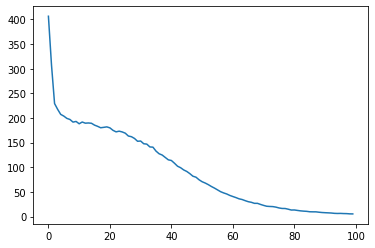

In [6]:
plt.plot(range(len(ppl_list)), ppl_list)
plt.show()